In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap
# Only import what you need from scipy to keep namespace clean
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from scipy.stats import gaussian_kde
import numpy as np
import h5py

# --- Path Configuration ---
# Uses pathlib for robust, OS-agnostic path handling
# Notebook: .../ROC_CI_pred/python_notebooks/Fig.3_plotPosteriors.ipynb
# Parent:   .../ROC_CI_pred/
current_dir = Path.cwd()
project_root = current_dir.parent 
ppath = project_root / "data"          # Points to .../ROC_CI_pred/data
save_fig_path = project_root / "plots" # Points to .../ROC_CI_pred/plots

# Ensure the plots directory exists
save_fig_path.mkdir(parents=True, exist_ok=True)

# --- Colormap Configuration ---
# Modern way to resample colormaps without manual linspace
clist = []
for cname in ["winter", "spring"]:
    clist.append(plt.get_cmap(cname).resampled(10))

# --- Figure Parameters ---
FigParams = {
    "fig_size": 6,
    "font1": {"fontname": "Arial", "size": 30},
    "font2": {"fontname": "Arial", "size": 30},
    "line_w": 2,
    "colors_maps": clist,
    "colors_names": ["royalblue", "olivedrab", "darkorange", "firebrick"],
    "saveFigPath": str(save_fig_path),
    "ErrorBar": {
        'ErrDist': [0.4, 0.4],
        'ErrSize': 1,
        'ErrWid': 4,
        'sizedots': 10,
        'ErrColor': ["royalblue", "olivedrab", "darkorange", "firebrick"],
        'DotsColor': ["royalblue", "olivedrab", "darkorange", "firebrick"],
        'sizeMean': 25
    },
}

def packParams():
    return (
        FigParams["fig_size"],
        FigParams["font1"],
        FigParams["font2"],
        FigParams["line_w"],
        FigParams["colors_maps"],
        FigParams["colors_names"],
        FigParams["saveFigPath"],
    )

def vector_subtract(direction1, speed1, direction2, speed2):
    """
    Subtracts vector2 from vector1 (v1 - v2).
    Inputs: Direction in degrees, Speed (magnitude).
    Returns: (Result Direction in degrees, Result Speed).
    """
    # Convert direction and speed to Cartesian coordinates
    # np.radians handles degree-to-radian conversion
    x1 = speed1 * np.cos(np.radians(direction1))
    y1 = speed1 * np.sin(np.radians(direction1))
    x2 = speed2 * np.cos(np.radians(direction2))
    y2 = speed2 * np.sin(np.radians(direction2))
    
    # Subtract the vectors
    x_diff = x1 - x2
    y_diff = y1 - y2
    
    # Convert the result back to direction and speed
    result_speed = np.sqrt(x_diff**2 + y_diff**2)
    # arctan2 returns values in [-pi, pi], degrees in [-180, 180]
    result_direction = np.degrees(np.arctan2(y_diff, x_diff))
    
    # Ensure direction is in the range [-180, 180)
    if result_direction >= 180:
        result_direction -= 360
    elif result_direction < -180:
        result_direction += 360
    
    return result_direction, result_speed

# Posterior beleifs of an example observer assuming relative motion variable

In [2]:
# --- 1. Unpack Figure Parameters
(figS, f_font1, f_font2, line_w, clist, colors_names, sp) = packParams()

In [3]:
# Ensure save path has trailing slash if using string concatenation later
if not sp.endswith('/'): sp += '/'

# --- 2. Data Loading ---
files = [
    'post_vel_relVar_subj2_struct1.mat',
    'post_vel_relVar_subj2_struct2.mat',
    'post_vel_relVar_subj2_struct3.mat',
    'post_vel_relVar_subj2_struct4.mat',
    'post_vel_relVar_subj2_struct5.mat',
    'post_vel_relVar_subj2_structAll.mat',
    'post_struct_relVar_subj2.mat'
]

struct_all = []
vel_post = None
str_post = None

print(f"Loading data from: {ppath}")

# Loop to load the individual structures (and the last one)
for n in files:
    file_path = ppath / n
    if not file_path.exists():
        print(f"Warning: File not found: {file_path}")
        continue
        
    with h5py.File(file_path, 'r') as file:
        # Load datasets common to all files
        # keys: dir_post, spe_post
        if 'structAll' in n:
            print(f"Loading detailed data from {n}...")
            vel_post = np.array(file['vel_post'])
            print(f"Loaded vel_post: {vel_post.shape}")
        elif 'struct_' in n: 
            # Fallback name guess just in case
            str_post = np.array(file['struct_post'])
        else:
            dir_post = np.array(file['dir_post'])
            spd_post = np.array(file['spe_post'])
            struct_all.append([dir_post, spd_post])
            # If this is the 'All' file, load the extra datasets needed for plotting


Loading data from: /Users/glengyel/My Drive/Gabor/Rochester/ROC_CI_pred/data
Loading detailed data from post_vel_relVar_subj2_structAll.mat...
Loaded vel_post: (2, 1000, 91, 91, 5, 5)


Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 0.0 surround=0
Best bandwidth found: 0.100
Max density: 2.6071018223583593 Min density: -50.19986138449166
Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0
Best bandwidth found: 0.100
Max density: 1.2782696116304244 Min density: -775.5316004051598
Speed: 4cps
direction: center= 132.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0


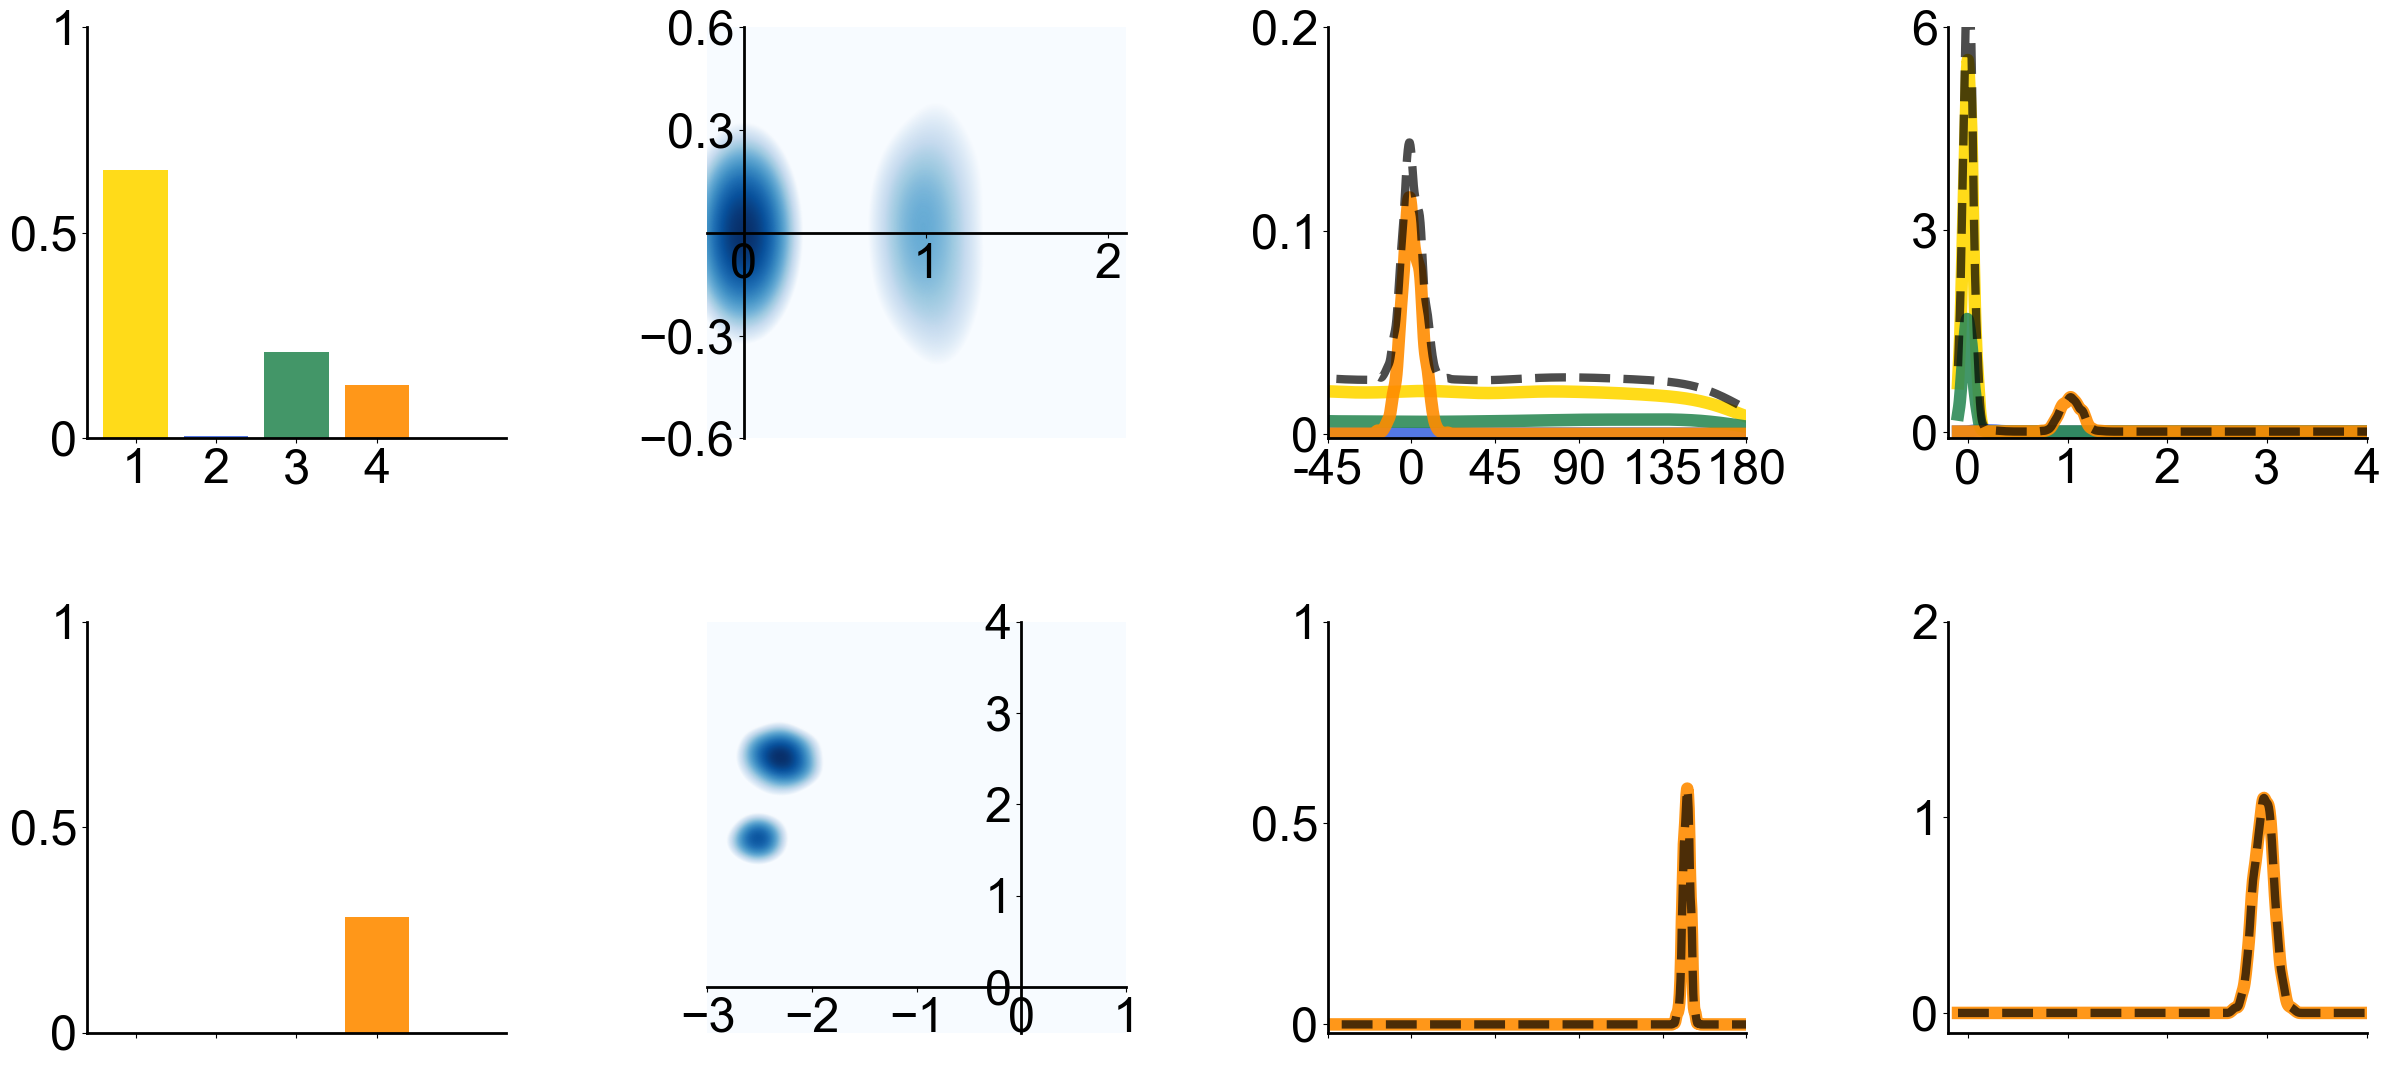

In [4]:
# Infer 'l' from data dimensions to avoid undefined variable error
# Assuming dimension 2 is the center direction dimension
n_degrees = vel_post.shape[2] 
degree_values = np.linspace(-180, 180, n_degrees)

xtck_ = [-180, -135, -90, -45, 0, 45, 90, 135, 180]
x_evalD = np.linspace(-180, 180, num=1000)
x_evalS = np.linspace(-0.1, 6, num=1000)
bandwidths = {'bandwidth': np.logspace(-1, 1, 20)}
ms = 20

CM = ["Purples", "Blues", "Greens", "Oranges", "Reds"]
colors = ["gold", "royalblue", "seagreen", "darkorange", "olivedrab"]
cNames = ["CS Integration", "CS Segmentation", "Center Reference", "Intermediate Reference", "Independent", "All"]
struct_id = [13, 14, 15, 16, 4, 0]

# --- 4. Main Plotting Loop ---
p = 0
bw = 0.2
cs, ss = 2, 2
degS = 45

# Indices for specific center directions
xC = [45, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76,
      78, 80, 82, 84, 86, 88, 90]

XL = [[-0.2, 2.1], [-3., 1], [-4, 0.5]]
YL = [[-0.6, 0.6], [-0.5, 4], [-0.6, 0.6]]
xt = [[0, 1, 2, 3, 4, 5], [-3, -2, -1, 0, 1], [-4, -3, -2, -1, 0]]
yt = [[-0.6, -0.3, 0.3, 0.6], [0, 1, 2, 3, 4], [-0.6, -0.3, 0.3, 0.6]]

_, axs = plt.subplots(2,4, figsize=(figS*4, figS*1.8))
axs = axs.flatten()

for si,six in enumerate([0,16]):
    for i in range(4):
        degC=xC[six]
        print("Speed: 4cps")
        print("direction: center=",degree_values[degC], "surround=0")
        
        bw=0.03 if degC==90 else 0.2
        vmx = 25 if si==0 else 3
        ax = axs[p]
        if i==1:
            x=vel_post[0,:,degC,degS,cs,ss]
            y=vel_post[1,:,degC,degS,cs,ss]
            # if si==0:
            #     D = np.vstack([x[x!=0], y[y!=0]])
            # else:
            D = np.vstack([x, y])
            bwv=0.6 if si==0 else 0.4
            #kde2 = gaussian_kde(D,bw_method=bwv)
            # Define grid range based on the data
            #e = 0.5
            xl = XL[si]
            yl = YL[si]
            #x_min, x_max = x.min() - e, x.max() + e
            #y_min, y_max = y.min() - e, y.max() + e
            xx, yy = np.meshgrid(np.linspace(xl[0], xl[1], 1000), np.linspace(yl[0], yl[1], 1000))
            grid_coords = np.vstack([xx.ravel(), yy.ravel()])
            #zz2 = kde2(grid_coords).reshape(xx.shape)
            #zz2 = kde2.logpdf(grid_coords).reshape(xx.shape)
            # 2. Use cross-validation to find the best bandwidth
            grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                                bandwidths,
                                cv=5) # 5-fold cross-validation
            grid.fit(D.T)
            print(f"Best bandwidth found: {grid.best_params_['bandwidth']:.3f}")
            # 3. Use the best estimator found by the grid search
            kde_best = grid.best_estimator_
            # 4. Evaluate and plot
            zz2 = kde_best.score_samples(grid_coords.T).reshape(xx.shape)
            print("Max density:", zz2.max(), "Min density:", zz2.min())
            #ax.pcolormesh(xx, yy, zz2, cmap=CM[1], shading='gouraud',vmin=0, vmax=vmx)#,vmin=0, vmax=0.05)
            ax.pcolormesh(xx, yy, zz2, cmap=CM[1], shading='gouraud',vmin=-zz2.max(), vmax=zz2.max())#,vmin=0, vmax=0.05)
            #if si==0:
                #ax.plot([0],[0], "o", markersize=line_w+ms-6, markerfacecolor="darkblue") #markeredgecolor="lightblue", markeredgewidth=line_w+4)
                #ax.plot(x,y)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            # Move axes to the center (x=0 and y=0)
            ax.spines["left"].set_position(("data", 0))  # Position y-axis at x=0
            ax.spines["bottom"].set_position(("data", 0))  # Position x-axis at y=0
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)

            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(xt[si])
            ax.yaxis.set_ticks(yt[si])
            ax.set_xlim(xl[0], xl[1])
            ax.set_ylim(yl[0], yl[1])

        elif i==3:
            ytck = [0,1,2,3,4]
            #ytckL = ["0","3","6","9","12"]
            mv2 = []
            for c,P in enumerate(struct_all[:-1]):
                Y0 = P[1][:,degC,degS,cs,ss].copy()
                if (Y0==0).all():
                    Y0 = np.random.normal(loc=0,scale=0.05,size=2000)
                kde = gaussian_kde(Y0, bw_method=0.2)
                Y = kde(x_evalS)
                X = x_evalS.copy()
                z = (np.sum(str_post[:,degC,degS,cs,ss]==struct_id[c])/str_post.shape[0])
                M = Y*z
                if z!=0:
                    ax.plot(X,M, '-',  color=colors[c], linewidth=line_w+7, alpha=0.9)
                mv2.append(M)
            ax.plot(x_evalS, np.sum(mv2, axis=0), '--',  color="k", linewidth=line_w+4, alpha=0.7)
            #ax.plot([3,3.15,3.4,3.8],np.zeros(4)+0.003,  "o", markersize=line_w+ms,markerfacecolor="lightblue", markeredgecolor="k", markeredgewidth=line_w)
            #ax.plot([12,15],np.zeros(2), "-", color="royalblue", linewidth=line_w+6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(ytck)
            
            if p==3:
                ax.xaxis.set_ticklabels(ytck)
            else:
                ax.xaxis.set_ticklabels([])
            ax.set_xlim(-0.2, 4)
            if si==0:
                ax.set_ylim(-0.1, 6)
                ax.yaxis.set_ticks([0,3,6])
                ax.yaxis.set_ticklabels([0, 3, 6])
            else:
                ax.set_ylim(-0.1, 2)
                ax.yaxis.set_ticks([0,1,2])
                ax.yaxis.set_ticklabels([0, 1, 2])
        elif i==0:
            for c,P in enumerate(struct_all[:-1]):
                z = (np.sum(str_post[:,degC,degS,cs,ss]==struct_id[c])/str_post.shape[0])
                ax.bar(c, z, color=colors[c], alpha=0.9)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(range(len(struct_all)-1))
            #ax.xaxis.set_ticklabels(range(1,len(struct_all)))
            ax.yaxis.set_ticks([0,0.5, 1])
            ax.set_ylim(0, 1)
            ax.yaxis.set_ticklabels([0, 0.5, 1])
            ax.set_xlim(-0.6, 4.6)
            if p==0:
                ax.xaxis.set_ticklabels(range(1,len(struct_all)))
            else:
                ax.xaxis.set_ticklabels([])
        elif i==2:
            mv = []
            for c,P in enumerate(struct_all[:-1]):
                Y0 = P[0][:,degC,degS,cs,ss]
                Y0[np.isnan(Y0)] = np.random.uniform(-180, 180, sum(np.isnan(Y0)))
                kde = gaussian_kde(Y0, bw_method=bw)
                Y = kde(x_evalD)
                X = x_evalD.copy()
                z = (np.sum(str_post[:,degC,degS,cs,ss]==struct_id[c])/str_post.shape[0])
                M = Y*z
                if z!=0:
                    ax.plot(X,M, '-',  color=colors[c], linewidth=line_w+7, alpha=0.9)
                mv.append(M)
            #print(np.sum(mv, axis=0))
            ax.plot(x_evalD, np.sum(mv, axis=0), '--',  color="k", linewidth=line_w+4, alpha=0.7)
            #ax.plot([108,115,117,120],np.zeros(4)+0.001,  "o", markersize=line_w+ms,markerfacecolor="lightblue", markeredgecolor="k", markeredgewidth=line_w)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(xtck_)
            
            if p==2:
                ax.xaxis.set_ticklabels(xtck_)
            else:
                ax.xaxis.set_ticklabels([])
            ax.set_xlim(-45, 180)
            # if p in [10,12,14]:
            #     ax.yaxis.set_ticks([0,0.06, 0.12])
            #     ax.set_ylim(-0.015, 0.12)
            #     ax.yaxis.set_ticklabels([0, 0.1, 0.2])
            # else:
            if si==0:
                ax.yaxis.set_ticks([0, 0.009, 0.018])
                ax.set_ylim(-0.0002, 0.018)
                ax.yaxis.set_ticklabels([0, 0.1, 0.2])
            else:
                ax.yaxis.set_ticks([0,0.05, 0.1])
                ax.set_ylim(-0.002, 0.1)
                ax.yaxis.set_ticklabels([0, 0.5, 1])
            #stimType = 'Center direction = '+str(round(xL[ti]))
            #ax.annotate(stimType, xy=(0.1,1.05),xycoords='axes fraction',fontsize=f_font1["size"])
        p+=1
    #ax.set_xlabel(" ")
    #ax.set_ylabel(L[i], **f_font2)
    #plt.tight_layout()
plt.tight_layout(h_pad=8, w_pad=8)
plt.savefig(sp + "MixPostDir_subj2_relative_surr0.pdf")
plt.show()

In [5]:
files = [
         'post_vel_grpVar_subj2_struct1.mat',
            'post_vel_grpVar_subj2_struct2.mat',
            'post_vel_grpVar_subj2_struct3.mat',
            'post_vel_grpVar_subj2_struct4.mat',
            'post_vel_grpVar_subj2_struct5.mat',
            'post_vel_grpVar_subj2_structAll.mat'
]

struct_all = []
vel_post = None

print(f"Loading data from: {ppath}")

# Loop to load the individual structures (and the last one)
for n in files:
    file_path = ppath / n
    if not file_path.exists():
        print(f"Warning: File not found: {file_path}")
        continue
        
    with h5py.File(file_path, 'r') as file:
        # Load datasets common to all files
        # keys: dir_post, spe_post
        if 'structAll' in n:
            print(f"Loading detailed data from {n}...")
            vel_post = np.array(file['vel_post'])
            print(f"Loaded vel_post: {vel_post.shape}")
        else:
            dir_post = np.array(file['dir_post'])
            spd_post = np.array(file['spe_post'])
            struct_all.append([dir_post, spd_post])
            # If this is the 'All' file, load the extra datasets needed for plotting

Loading data from: /Users/glengyel/My Drive/Gabor/Rochester/ROC_CI_pred/data
Loading detailed data from post_vel_grpVar_subj2_structAll.mat...
Loaded vel_post: (2, 1000, 91, 91, 5, 5)


Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 0.0 surround=0
Found 529 values inside the range [3.99, 4.01].
Found 471 values outside the range.
Will replace 211 values.
Best bandwidth found: 0.100
Max density: 2.025764464181247 Min density: -518.8168252833831
Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0
Found 0 values inside the range [3.99, 4.01].
Found 1000 values outside the range.
Will replace 0 values.
Best bandwidth found: 0.100
Max density: 2.388906578708621 Min density: -854.8061196277041
Speed: 4cps
direction: center= 132.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0


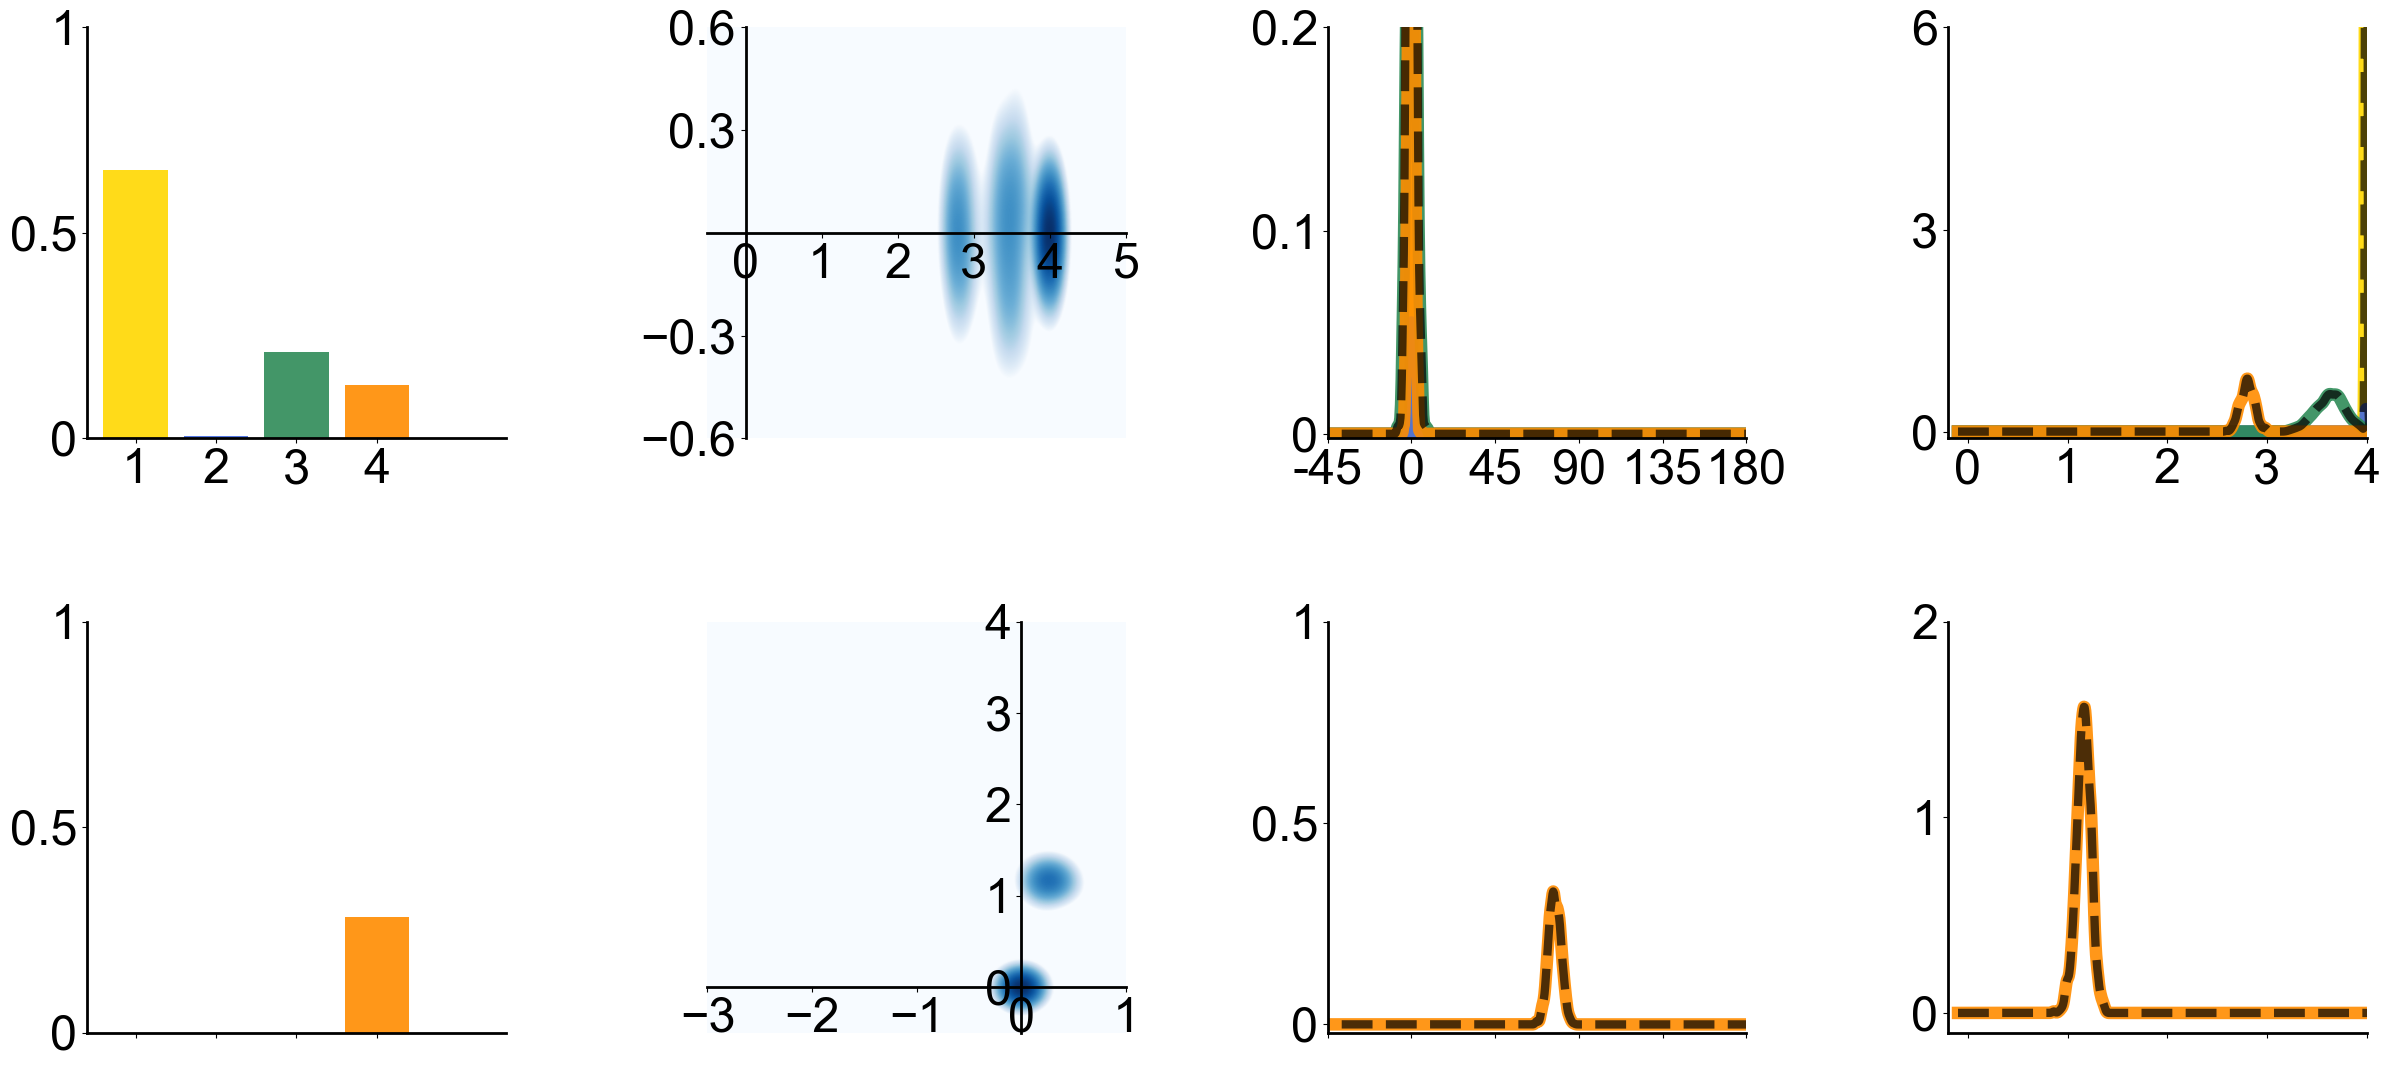

In [6]:
XL = [[-0.5, 5],
      [-3, 1],
      [-0.6, 0.6]]
YL = [[-0.6, 0.6],
      [-0.5, 4],
      [-0.5, 1.5],
      [-0.6, 0.6]]
xt = [[0,1,2,3,4,5],
      [-3,-2,-1,0,1],
      [-0.6,-0.3,0.3,0.6]]
yt = [[-0.6,-0.3,0.3,0.6],
      [0,1,2,3,4],
      [-0.6,-0.3,0.3,0.6]]
_, axs = plt.subplots(2,4, figsize=(figS*4, figS*1.8))
axs = axs.flatten()
p=0
for si,six in enumerate([0,16]):
    for i in range(4):
        degC=xC[six]
        print("Speed: 4cps")
        print("direction: center=",degree_values[degC], "surround=0")
        
        bw=0.03 if degC==90 else 0.2
        vmx = 4 if si==0 else 25
        ax = axs[p]
        if i==1:
            x=vel_post[0,:,degC,degS,cs,ss]
            y=vel_post[1,:,degC,degS,cs,ss]
            # if si==1:
            #     D = np.vstack([x[x!=0], y[y!=0]])
            # else:
            ix4 = (x > 3.99) & (x < 4.01)
            # np.where gives us the actual integer indices where the condition is True
            target_indices = np.where(ix4)[0]
            source_indices = np.where(np.invert(ix4))[0]
            # Check how many we found
            print(f"Found {len(target_indices)} values inside the range [3.99, 4.01].")
            print(f"Found {len(source_indices)} values outside the range.")
            # 2. Determine how many values to replace
            # Calculate 40% of the number of target values
            num_to_replace = int(len(target_indices) * 0.4)
            print(f"Will replace {num_to_replace} values.")
            ix4_ = np.random.choice(target_indices, size=num_to_replace, replace=False)
            # 4. Randomly select the source indices (ix4not_) from the source group
            # We choose *with* replacement, allowing a single "good" outside value to be copied multiple times,
            # effectively overweighting the source distribution.
            ix4not_ = np.random.choice(source_indices, size=num_to_replace, replace=True)
            # 5. Perform the replacement on the original array slice
            x[ix4_] = x[ix4not_]
            y[ix4_] = y[ix4not_]
            D = np.vstack([x, y])
            #bwv=0.4 #if degC==45 else 0.4
            #kde2 = gaussian_kde(D,bw_method=bwv)
            # Define grid range based on the data
            #e = 0.5
            xl = XL[si]
            yl = YL[si]
            #x_min, x_max = x.min() - e, x.max() + e
            #y_min, y_max = y.min() - e, y.max() + e
            xx, yy = np.meshgrid(np.linspace(xl[0], xl[1], 1000), np.linspace(yl[0], yl[1], 1000))
            grid_coords = np.vstack([xx.ravel(), yy.ravel()])
            #zz2 = kde2.logpdf(grid_coords).reshape(xx.shape)
            # 2. Use cross-validation to find the best bandwidth
            grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                                bandwidths,
                                cv=5) # 5-fold cross-validation
            grid.fit(D.T)
            print(f"Best bandwidth found: {grid.best_params_['bandwidth']:.3f}")
            # 3. Use the best estimator found by the grid search
            kde_best = grid.best_estimator_
            # 4. Evaluate and plot
            zz2 = kde_best.score_samples(grid_coords.T).reshape(xx.shape)
            print("Max density:", zz2.max(), "Min density:", zz2.min())
            ax.pcolormesh(xx, yy, zz2, cmap=CM[1], shading='gouraud',vmin=-zz2.max(), vmax=zz2.max())#,vmin=0, vmax=0.05)
            #if si==1:
            #    ax.plot([0],[0], "o", markersize=line_w+ms-6, markerfacecolor="darkblue") #markeredgecolor="lightblue", markeredgewidth=line_w+4)
                #ax.plot(x,y)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            # Move axes to the center (x=0 and y=0)
            ax.spines["left"].set_position(("data", 0))  # Position y-axis at x=0
            ax.spines["bottom"].set_position(("data", 0))  # Position x-axis at y=0
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)

            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(xt[si])
            ax.yaxis.set_ticks(yt[si])
            ax.set_xlim(xl[0], xl[1])
            ax.set_ylim(yl[0], yl[1])

        elif i==3:
            ytck = [0,1,2,3,4]
            #ytckL = ["0","3","6","9","12"]
            mv2 = []
            for c,P in enumerate(struct_all[:-1]):
                Y0 = P[1][:,degC,degS,cs,ss].copy()
                if (Y0==0).all():
                    Y0 = np.random.normal(loc=0,scale=0.05,size=2000)
                kde = gaussian_kde(Y0, bw_method=0.2)
                Y = kde(x_evalS)
                X = x_evalS.copy()
                z = (np.sum(str_post[:,degC,degS,cs,ss]==struct_id[c])/str_post.shape[0])
                M = Y*z
                if z!=0:
                    ax.plot(X,M, '-',  color=colors[c], linewidth=line_w+7, alpha=0.9)
                mv2.append(M)
            ax.plot(x_evalS, np.sum(mv2, axis=0), '--',  color="k", linewidth=line_w+4, alpha=0.7)
            #ax.plot([3,3.15,3.4,3.8],np.zeros(4)+0.003,  "o", markersize=line_w+ms,markerfacecolor="lightblue", markeredgecolor="k", markeredgewidth=line_w)
            #ax.plot([12,15],np.zeros(2), "-", color="royalblue", linewidth=line_w+6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(ytck)
            
            if p==3:
                ax.xaxis.set_ticklabels(ytck)
            else:
                ax.xaxis.set_ticklabels([])
            ax.set_xlim(-0.2, 4)
            if si==0:
                ax.set_ylim(-0.1, 6)
                ax.yaxis.set_ticks([0,3,6])
                ax.yaxis.set_ticklabels([0, 3, 6])
            else:
                ax.set_ylim(-0.1, 2)
                ax.yaxis.set_ticks([0,1,2])
                ax.yaxis.set_ticklabels([0, 1, 2])
        elif i==0:
            for c,P in enumerate(struct_all[:-1]):
                z = (np.sum(str_post[:,degC,degS,cs,ss]==struct_id[c])/str_post.shape[0])
                ax.bar(c, z, color=colors[c], alpha=0.9)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(range(len(struct_all)-1))
            #ax.xaxis.set_ticklabels(range(1,len(struct_all)))
            ax.yaxis.set_ticks([0,0.5, 1])
            ax.set_ylim(0, 1)
            ax.yaxis.set_ticklabels([0, 0.5, 1])
            ax.set_xlim(-0.6, 4.6)
            if p==0:
                ax.xaxis.set_ticklabels(range(1,len(struct_all)))
            else:
                ax.xaxis.set_ticklabels([])
        elif i==2:
            mv = []
            for c,P in enumerate(struct_all[:-1]):
                Y0 = P[0][:,degC,degS,cs,ss]
                Y0[np.isnan(Y0)] = np.random.uniform(-180, 180, sum(np.isnan(Y0)))
                kde = gaussian_kde(Y0, bw_method=bw)
                Y = kde(x_evalD)
                X = x_evalD.copy()
                z = (np.sum(str_post[:,degC,degS,cs,ss]==struct_id[c])/str_post.shape[0])
                M = Y*z
                if z!=0:
                    ax.plot(X,M, '-',  color=colors[c], linewidth=line_w+7, alpha=0.9)
                mv.append(M)
            #print(np.sum(mv, axis=0))
            ax.plot(x_evalD, np.sum(mv, axis=0), '--',  color="k", linewidth=line_w+4, alpha=0.7)
            #ax.plot([108,115,117,120],np.zeros(4)+0.001,  "o", markersize=line_w+ms,markerfacecolor="lightblue", markeredgecolor="k", markeredgewidth=line_w)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(xtck_)
            
            if p==2:
                ax.xaxis.set_ticklabels(xtck_)
            else:
                ax.xaxis.set_ticklabels([])
            ax.set_xlim(-45, 180)
            # if p in [10,12,14]:
            #     ax.yaxis.set_ticks([0,0.06, 0.12])
            #     ax.set_ylim(-0.015, 0.12)
            #     ax.yaxis.set_ticklabels([0, 0.1, 0.2])
            # else:
            if si==0:
                ax.yaxis.set_ticks([0, 0.009, 0.018])
                ax.set_ylim(-0.0002, 0.018)
                ax.yaxis.set_ticklabels([0, 0.1, 0.2])
            else:
                ax.yaxis.set_ticks([0,0.05, 0.1])
                ax.set_ylim(-0.002, 0.1)
                ax.yaxis.set_ticklabels([0, 0.5, 1])
            #stimType = 'Center direction = '+str(round(xL[ti]))
            #ax.annotate(stimType, xy=(0.1,1.05),xycoords='axes fraction',fontsize=f_font1["size"])
        p+=1
    #ax.set_xlabel(" ")
    #ax.set_ylabel(L[i], **f_font2)
    #plt.tight_layout()
plt.tight_layout(h_pad=8, w_pad=8)
plt.savefig(sp+"MixPostDir_subj2_group_surr0.pdf")
plt.show()

In [8]:
# open the file in read modefile_path = ppath / n
file_path = ppath / 'post_vel_retVar_subj2_structAll.mat'
if not file_path.exists():
    print(f"Warning: File not found: {file_path}")
    
with h5py.File(file_path, 'r') as file:
    # list all the keys in the root group
    print(list(file.keys()))

    #access a dataset
    vel_postR = file['vel_post']
    print(vel_postR.shape)
    vel_postR = np.array(vel_postR)
    print(vel_postR.shape)

    dir_postR = file['dir_post']
    #print(dir_post.shape)
    dir_postR = np.array(dir_postR)
    print(dir_postR.shape)

    # access a dataset
    spd_postR = file['spe_post']
    #print(spd_post.shape)
    spd_postR = np.array(spd_postR)
    print(spd_postR.shape)

['#refs#', '#subsystem#', 'c', 'c_dir', 'c_speed', 'causalStruct', 'dir_post', 'dir_vec', 'gap', 'id1', 'lenCaus', 'len_c', 'len_c_speed', 'len_s', 'len_s_speed', 'model', 'model_params', 'model_type', 'models_all', 'n', 'ndots', 'ndots_all', 'noise', 'ns', 'num_trials', 'point', 's', 's_dir', 's_speed', 'sig_id', 'spe_post', 'speed_vec', 'struct_post', 'subid', 'subid_all', 'varType', 'vel_post']
(2, 1000, 91, 91, 5, 5)
(2, 1000, 91, 91, 5, 5)
(1000, 91, 91, 5, 5)
(1000, 91, 91, 5, 5)


Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 0.0 surround=0
Found 0 values inside the range [3.99, 4.01].
Found 1000 values outside the range.
Will replace 0 values.
Best bandwidth found: 0.100
Max density: 2.3583768813554222 Min density: -601.1428851178516
Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 0.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0
Found 0 values inside the range [3.99, 4.01].
Found 1000 values outside the range.
Will replace 0 values.
Best bandwidth found: 0.100
Max density: 1.3419389138782094 Min density: -821.2452832224636
Speed: 4cps
direction: center= 132.0 surround=0
Speed: 4cps
direction: center= 132.0 surround=0


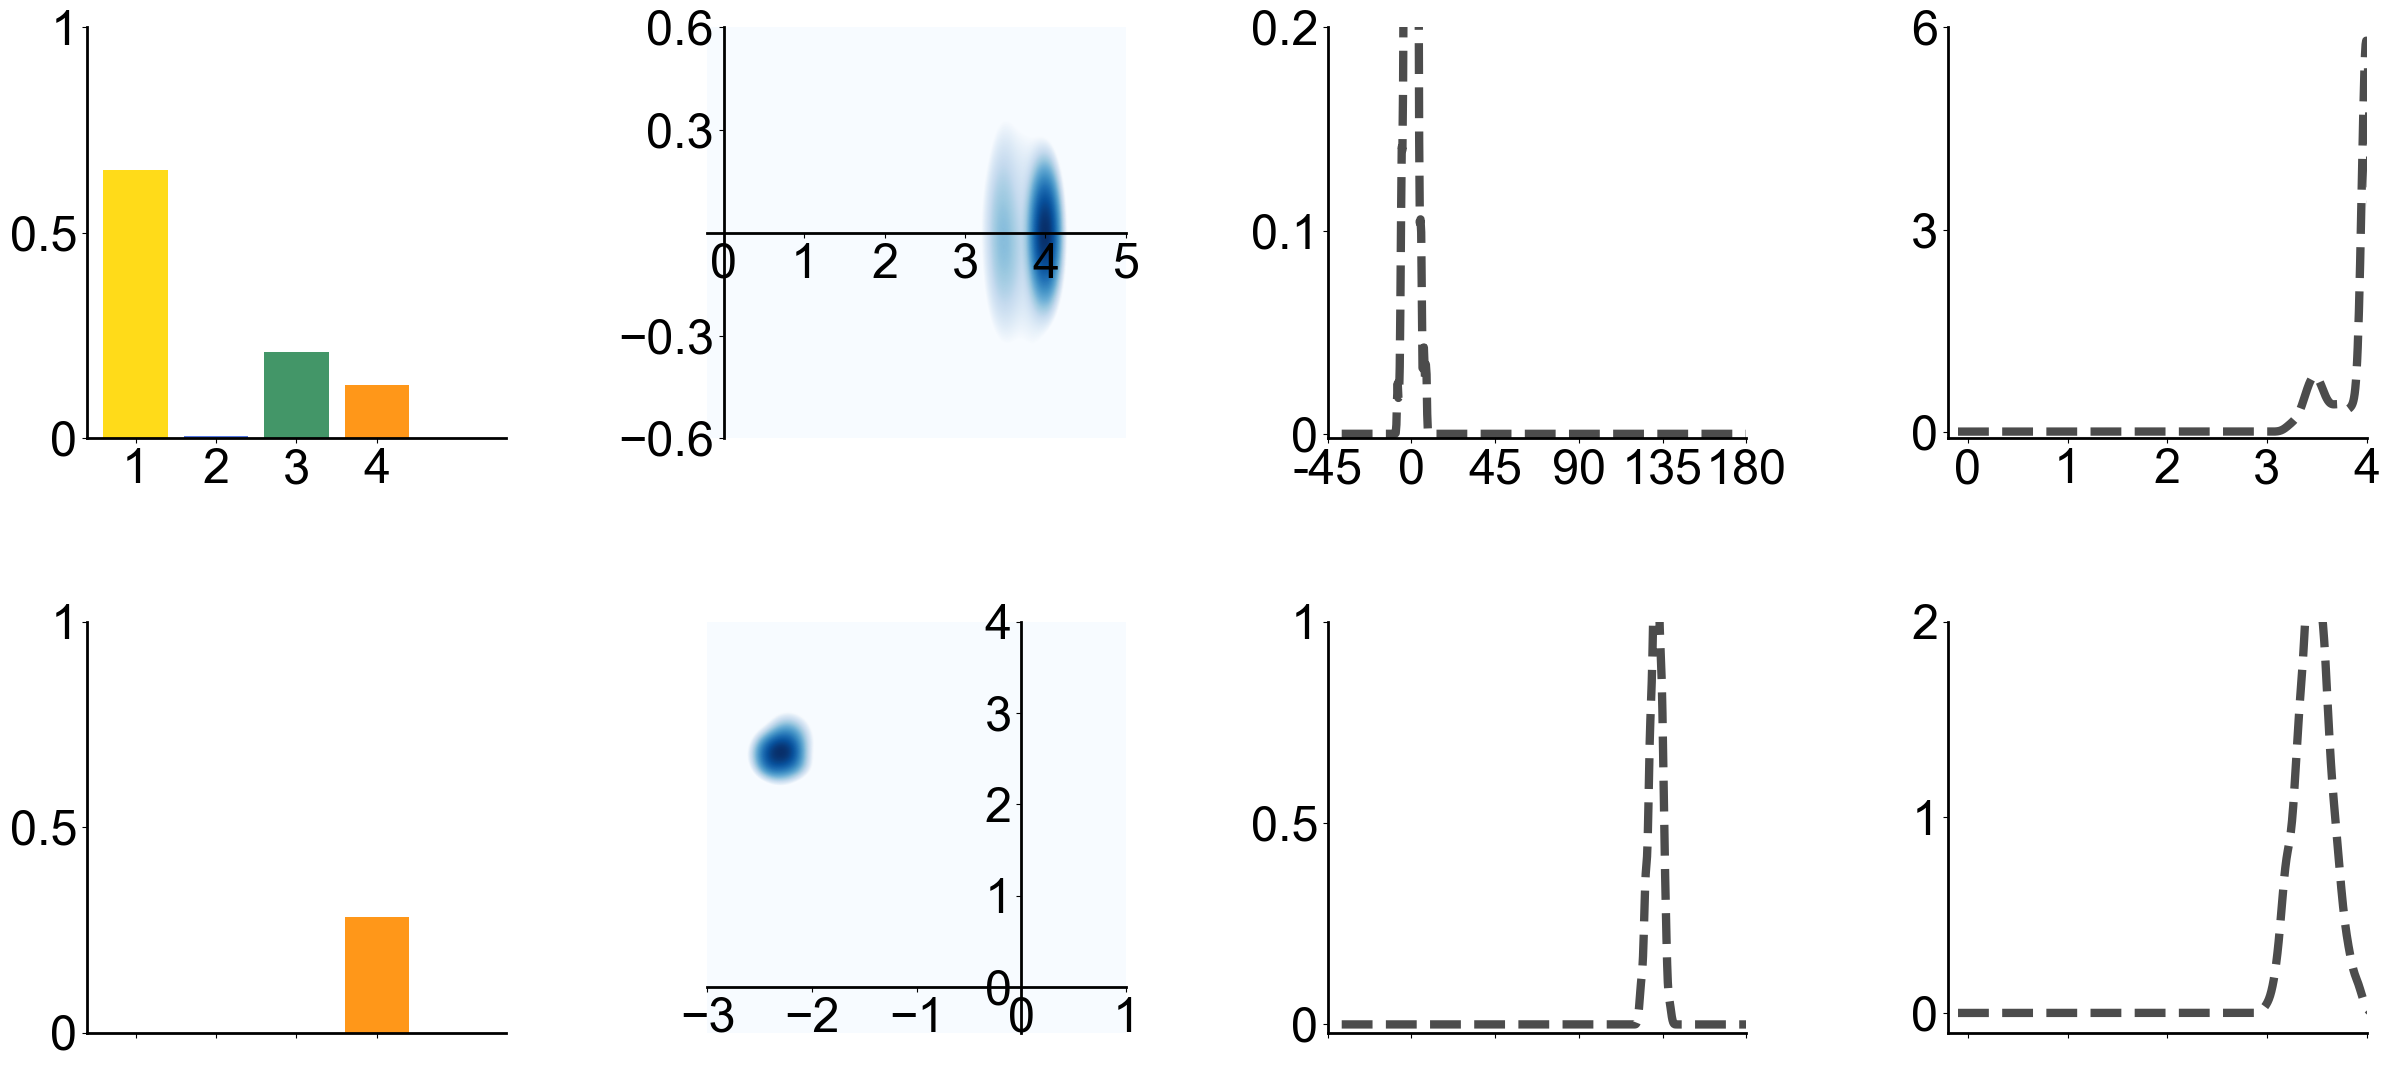

In [9]:
XL = [[-0.2, 5],
      [-3., 1],#[-3., 0.5],
      [-4, 0.5]]
YL = [[-0.6, 0.6],
       [-0.5, 4],#[-0.5, 3],
      [-0.6, 0.6]]
xt = [[0,1,2,3,4,5],
      [-3,-2,-1,0,1],#[-3,-2,-1],
      [-4,-3,-2,-1,0]]
yt = [[-0.6,-0.3,0.3,0.6],
      [0,1,2,3,4],#[0,1,2,3],
      [-0.6,-0.3,0.3,0.6]]
_, axs = plt.subplots(2,4, figsize=(figS*4, figS*1.8))
axs = axs.flatten()
p=0
for si,six in enumerate([0,16]):
    for i in range(4):
        degC=xC[six]
        print("Speed: 4cps")
        print("direction: center=",degree_values[degC], "surround=0")
        
        bw=0.03 if degC==90 else 0.2
        vmx = 10 if si==0 else 4
        ax = axs[p]
        if i==1:
            x=vel_postR[0,:,degC,degS,cs,ss].copy()
            y=vel_postR[1,:,degC,degS,cs,ss].copy()
            # if si==0:
            #     D = np.vstack([x[x!=0], y[y!=0]])
            # else:
            x4 = (x > 3.99) & (x < 4.01)
            # np.where gives us the actual integer indices where the condition is True
            target_indices = np.where(ix4)[0]
            source_indices = np.where(np.invert(ix4))[0]
            # Check how many we found
            print(f"Found {len(target_indices)} values inside the range [3.99, 4.01].")
            print(f"Found {len(source_indices)} values outside the range.")
            # 2. Determine how many values to replace
            # Calculate 40% of the number of target values
            num_to_replace = int(len(target_indices) * 0.50)
            print(f"Will replace {num_to_replace} values.")
            ix4_ = np.random.choice(target_indices, size=num_to_replace, replace=False)
            # 4. Randomly select the source indices (ix4not_) from the source group
            # We choose *with* replacement, allowing a single "good" outside value to be copied multiple times,
            # effectively overweighting the source distribution.
            ix4not_ = np.random.choice(source_indices, size=num_to_replace, replace=True)
            # 5. Perform the replacement on the original array slice
            x[ix4_] = x[ix4not_]
            y[ix4_] = y[ix4not_]
            D = np.vstack([x, y])
            bwv=0.4 #if degC==45 else 0.4
            kde2 = gaussian_kde(D,bw_method=bwv)
            # Define grid range based on the data
            #e = 0.5
            xl = XL[si]
            yl = YL[si]
            #x_min, x_max = x.min() - e, x.max() + e
            #y_min, y_max = y.min() - e, y.max() + e
            xx, yy = np.meshgrid(np.linspace(xl[0], xl[1], 1000), np.linspace(yl[0], yl[1], 1000))
            grid_coords = np.vstack([xx.ravel(), yy.ravel()])
            # zz2 = kde2(grid_coords).reshape(xx.shape)
            
            # ax.pcolormesh(xx, yy, zz2, cmap=CM[1], shading='gouraud',vmin=0, vmax=vmx)#,vmin=0, vmax=0.05)
            # if si==0:
            #     ax.plot([0],[0], "o", markersize=line_w+ms+5, markerfacecolor="darkblue") #markeredgecolor="lightblue", markeredgewidth=line_w+4)
                #ax.plot(x,y)
            # 2. Use cross-validation to find the best bandwidth
            grid = GridSearchCV(KernelDensity(kernel='gaussian'),
                                bandwidths,
                                cv=5) # 5-fold cross-validation
            grid.fit(D.T)
            print(f"Best bandwidth found: {grid.best_params_['bandwidth']:.3f}")
            # 3. Use the best estimator found by the grid search
            kde_best = grid.best_estimator_
            # 4. Evaluate and plot
            zz2 = kde_best.score_samples(grid_coords.T).reshape(xx.shape)
            print("Max density:", zz2.max(), "Min density:", zz2.min())
            #ax.pcolormesh(xx, yy, zz2, cmap=CM[1], shading='gouraud',vmin=0, vmax=vmx)#,vmin=0, vmax=0.05)
            ax.pcolormesh(xx, yy, zz2, cmap=CM[1], shading='gouraud',vmin=-zz2.max()+1.2, vmax=zz2.max())#,vmin=0, vmax=0.05)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            # Move axes to the center (x=0 and y=0)
            ax.spines["left"].set_position(("data", 0))  # Position y-axis at x=0
            ax.spines["bottom"].set_position(("data", 0))  # Position x-axis at y=0
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)

            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(xt[si])
            ax.yaxis.set_ticks(yt[si])
            ax.set_xlim(xl[0], xl[1])
            ax.set_ylim(yl[0], yl[1])

        elif i==3:
            ytck = [0,1,2,3,4]
            #ytckL = ["0","3","6","9","12"]
            mv2 = []
            Y0 = spd_postR[:,degC,degS,cs,ss]
            if (Y0==0).all():
                Y0 = np.random.normal(loc=0,scale=0.05,size=2000)
            kde = gaussian_kde(Y0, bw_method=0.2)
            Y = kde(x_evalS)
            #X = x_evalS.copy()
                # z = (np.sum(str_post[:,degC,degS,cs,ss]==struct_id[c])/str_post.shape[0])
                # M = Y*z
                # if z!=0:
                #     ax.plot(X,M, '-',  color=colors[c], linewidth=line_w+7, alpha=0.9)
                # mv2.append(M)
            ax.plot(x_evalS, Y, '--',  color="k", linewidth=line_w+4, alpha=0.7)
            #ax.plot([3,3.15,3.4,3.8],np.zeros(4)+0.003,  "o", markersize=line_w+ms,markerfacecolor="lightblue", markeredgecolor="k", markeredgewidth=line_w)
            #ax.plot([12,15],np.zeros(2), "-", color="royalblue", linewidth=line_w+6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(ytck)
            
            if p==3:
                ax.xaxis.set_ticklabels(ytck)
            else:
                ax.xaxis.set_ticklabels([])
            ax.set_xlim(-0.2, 4)
            if si==0:
                ax.set_ylim(-0.1, 6)
                ax.yaxis.set_ticks([0,3,6])
                ax.yaxis.set_ticklabels([0, 3, 6])
            else:
                ax.set_ylim(-0.1, 2)
                ax.yaxis.set_ticks([0,1,2])
                ax.yaxis.set_ticklabels([0, 1, 2])
        elif i==0:
            for c,P in enumerate(struct_all[:-1]):
                z = (np.sum(str_post[:,degC,degS,cs,ss]==struct_id[c])/str_post.shape[0])
                ax.bar(c, z, color=colors[c], alpha=0.9)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(range(len(struct_all)-1))
            #ax.xaxis.set_ticklabels(range(1,len(struct_all)))
            ax.yaxis.set_ticks([0,0.5, 1])
            ax.set_ylim(0, 1)
            ax.yaxis.set_ticklabels([0, 0.5, 1])
            ax.set_xlim(-0.6, 4.6)
            if p==0:
                ax.xaxis.set_ticklabels(range(1,len(struct_all)))
            else:
                ax.xaxis.set_ticklabels([])
        elif i==2:
            Y0 = dir_postR[:,degC,degS,cs,ss]
            Y0[np.isnan(Y0)] = np.random.uniform(-180, 180, sum(np.isnan(Y0)))
            kde = gaussian_kde(Y0, bw_method=bw)
            Y = kde(x_evalD)
            X = x_evalD.copy()
            ax.plot(X,Y, '--',  color="k", linewidth=line_w+4, alpha=0.7)
            #ax.plot([108,115,117,120],np.zeros(4)+0.001,  "o", markersize=line_w+ms,markerfacecolor="lightblue", markeredgecolor="k", markeredgewidth=line_w)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["bottom"].set_linewidth(line_w)
            ax.spines["left"].set_linewidth(line_w)
            ax.grid(False)
            for label in (ax.get_xticklabels()+ax.get_yticklabels()):
                label.set_fontname(f_font1["fontname"])
                label.set_fontsize(35)
            ax.xaxis.set_ticks(xtck_)
            
            if p==2:
                ax.xaxis.set_ticklabels(xtck_)
            else:
                ax.xaxis.set_ticklabels([])
            ax.set_xlim(-45, 180)
            # if p in [10,12,14]:
            #     ax.yaxis.set_ticks([0,0.06, 0.12])
            #     ax.set_ylim(-0.015, 0.12)
            #     ax.yaxis.set_ticklabels([0, 0.1, 0.2])
            # else:
            if si==0:
                ax.yaxis.set_ticks([0, 0.009, 0.018])
                ax.set_ylim(-0.0002, 0.018)
                ax.yaxis.set_ticklabels([0, 0.1, 0.2])
            else:
                ax.yaxis.set_ticks([0,0.05, 0.1])
                ax.set_ylim(-0.002, 0.1)
                ax.yaxis.set_ticklabels([0, 0.5, 1])
            #stimType = 'Center direction = '+str(round(xL[ti]))
            #ax.annotate(stimType, xy=(0.1,1.05),xycoords='axes fraction',fontsize=f_font1["size"])
        p+=1
    #ax.set_xlabel(" ")
    #ax.set_ylabel(L[i], **f_font2)
    #plt.tight_layout()
plt.tight_layout(h_pad=8, w_pad=8)
plt.savefig(sp+"MixPostDir_subj2_retina_surr0.pdf")
plt.show()

# Samples from example posteriors

Speed: 7cps
direction: center=45, surround=0


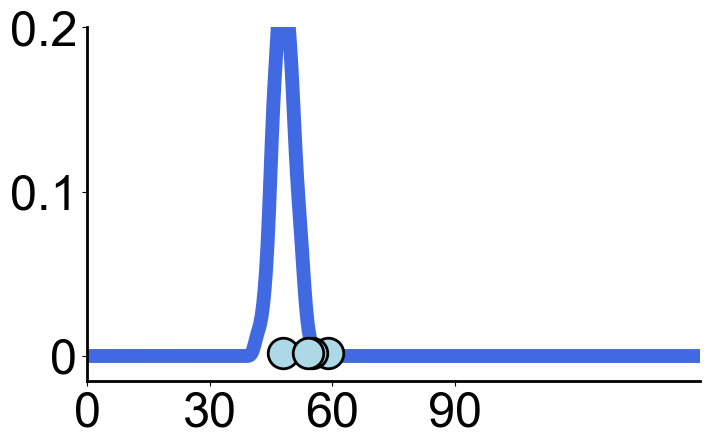

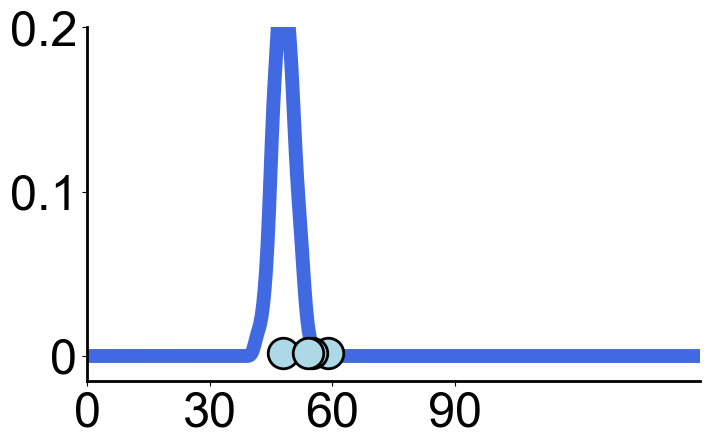

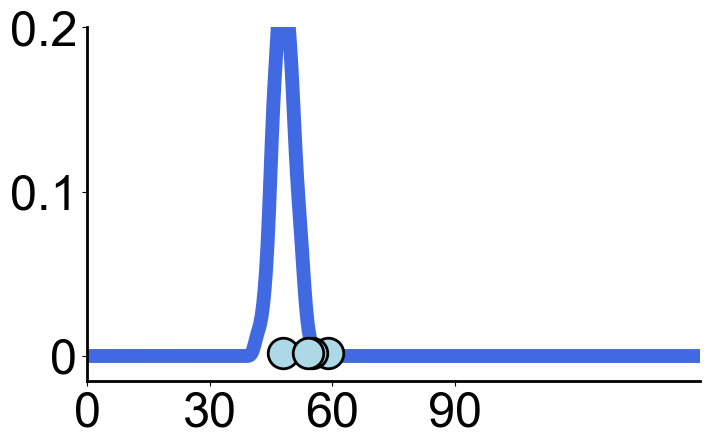

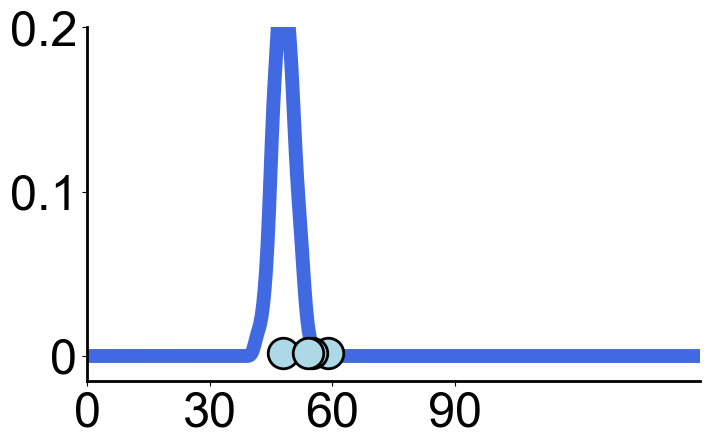

In [26]:
l = dir_post.shape[1]
ytck = [0,30,60,90]
x_eval = np.linspace(-180, 180, num=1000)
deg0 = int(np.round(l/2))
deg45 = deg0+int(np.round(l/8))
print("Speed: 7cps")
print("direction: center=45, surround=0")
ms=20

for c in range(4):
    _, ax = plt.subplots(1, 1, figsize=(figS*1.2, figS*.76))
    Y0 = dir_post[:,deg45,deg0,2,2]
    Y0[np.isnan(Y0)] = np.random.uniform(-180, 180, sum(np.isnan(Y0)))
    kde = gaussian_kde(Y0)
    Y = kde(x_eval)
    X = x_eval.copy()
    ax.plot(X,Y,  color="royalblue", linewidth=line_w+8)
    ax.plot([48,59,55,54],np.zeros(4)+0.001,  "o", markersize=line_w+ms,markerfacecolor="lightblue", markeredgecolor="k", markeredgewidth=line_w)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(line_w)
    ax.spines["bottom"].set_linewidth(line_w)
    ax.spines["left"].set_linewidth(line_w)
    ax.grid(False)
    for label in (ax.get_xticklabels()+ax.get_yticklabels()):
        label.set_fontname(f_font1["fontname"])
        label.set_fontsize(35)
    ax.xaxis.set_ticks(ytck)
    ax.yaxis.set_ticks([0,0.065, 0.13])
    ax.xaxis.set_ticklabels(ytck)
    ax.set_xlim(0, 150)
    ax.set_ylim(-0.01, 0.13)
    ax.yaxis.set_ticklabels([0, 0.1, 0.2])
    #ax.set_xlabel(" ")
    #ax.set_ylabel(L[i], **f_font2)
    plt.tight_layout()
    #plt.savefig(sp+"1PostDir_subj2_rel.pdf")
    plt.show()

# Example tuning curves

78.01801801801798 0.9999997527657009


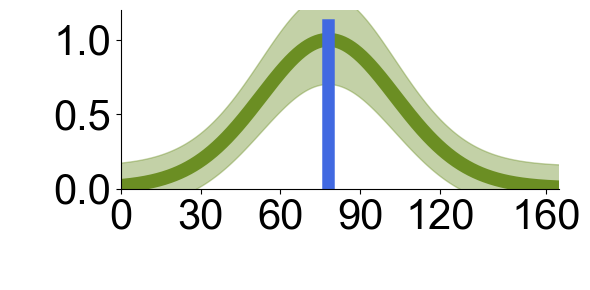

2.990990990990991 0.7992650300262982


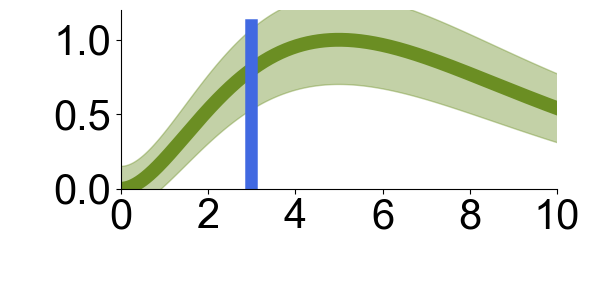

In [27]:
kappa=5
mu=78
xd = np.linspace(-180, 180, num=1000)
r_dir =  np.exp(kappa * (np.cos( ((xd-mu)/180)*np.pi )-1))

kappa=0.4
mu=0
n=2
xs = np.linspace(0, 18, num=1000)
r_spd = ((kappa*(xs - mu))**n * np.exp(-kappa*(xs - mu)))/(n**n * np.exp(-n))
c = ["royalblue", "olivedrab", "darkorange", "firebrick"]
error = 0.15
for i,Y in enumerate([r_dir, r_spd]):
    _, ax = plt.subplots(1, 1, figsize=(figS*1, figS*0.5))
    axins = ax
   
    if i==0:
        X = xd
        #axins.tick_params(right=False,bottom=False,top=False,labeltop=False,labelbottom=False)
        axins.set_xlabel(" ", **f_font1)
        axins.xaxis.set_ticks([0,30,60,90,120,160])
        axins.xaxis.set_ticklabels([0,30,60,90,120,160], **f_font1)
        v1,v2 = 77.9,78.1
        axins.set_xlim([0, 165])
        #xxr,xxrL = [0,0.01], ["0","0.01"]
    else:
        X=xs
        #axins.tick_params(left=False,right=False,bottom=False,top=False,labeltop=False,labelbottom=False)
        axins.set_xlabel(" ", **f_font1)
        axins.xaxis.set_ticks([0,2,4,6,8,10])
        axins.xaxis.set_ticklabels([0,2,4,6,8,10], **f_font1)
        #xxr,xxrL = [0, np.round(np.max(Y[t, :, r])*0.66,2)], ["0", str(np.round(np.max(Y[t, :, r])*0.66,2))]
        v1,v2 = 2.99,3.01

        axins.set_xlim([0, 10])
    axins.set_ylim([0,1.2])
    axins.yaxis.set_ticks([0,0.5,1])
    axins.fill_between(X, Y-(error+error*Y), Y+(error+error*Y), color=c[1], alpha=0.4)
    axins.plot(X, Y, "-", color=c[1], linewidth=line_w+8)
    ix = np.where((X<v2) & (X>v1))[0][0]
    axins.plot([X[ix],X[ix]], [0,1.1], "-", color=c[0], linewidth=line_w+7)
    print(X[ix],Y[ix])
    axins.spines["right"].set_visible(False)
    axins.spines["top"].set_visible(False)
    #axins.spines["bottom"].set_visible(False)
    axins.grid(False)
    axins.set_ylabel(" ", **f_font1)
    #axins.yaxis.set_ticklabels([])
    for labl in (axins.get_xticklabels()+axins.get_yticklabels()):
            labl.set_fontname(f_font1["fontname"])
            labl.set_fontsize(f_font1["size"])
    plt.tight_layout()
    plt.show()

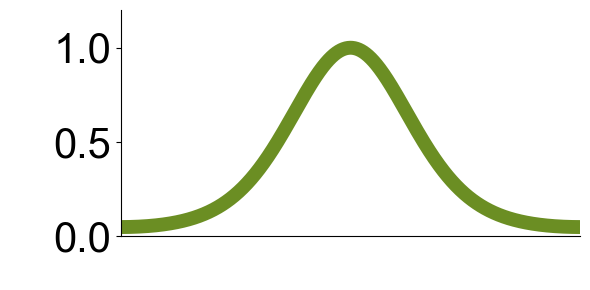

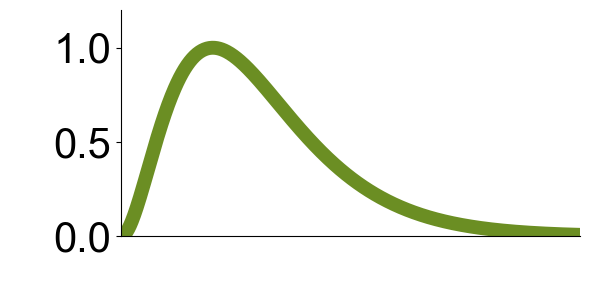

In [28]:
kappa=1.5
mu=0
xd = np.linspace(-180, 180, num=1000)
r_dir =  np.exp(kappa * (np.cos( ((xd-mu)/180)*np.pi )-1))

kappa=1
mu=0
n=2
xs = np.linspace(0, 18, num=1000)
r_spd = ((kappa*(xs - mu))**n * np.exp(-kappa*(xs - mu)))/(n**n * np.exp(-n))
c = ["royalblue", "olivedrab", "darkorange", "firebrick"]
error = 0.15
for i,Y in enumerate([r_dir, r_spd]):
    _, ax = plt.subplots(1, 1, figsize=(figS*1, figS*0.5))
    axins = ax
   
    if i==0:
        X = xd
        #axins.tick_params(right=False,bottom=False,top=False,labeltop=False,labelbottom=False)
        axins.set_xlabel(" ", **f_font1)
        axins.xaxis.set_ticks([ ])
        #axins.xaxis.set_ticklabels([0,30,60,90,120,160], **f_font1)
        v1,v2 = 77.9,78.1
        v1,v2 = -.9,1.1
        v1,v2 = 158.9,160.1
        axins.set_xlim([-180, 180])
        #xxr,xxrL = [0,0.01], ["0","0.01"]
    else:
        X=xs
        #axins.tick_params(left=False,right=False,bottom=False,top=False,labeltop=False,labelbottom=False)
        axins.set_xlabel(" ", **f_font1)
        axins.xaxis.set_ticks([ ])
        #axins.xaxis.set_ticklabels([0,2,4,6,8,10], **f_font1)
        #xxr,xxrL = [0, np.round(np.max(Y[t, :, r])*0.66,2)], ["0", str(np.round(np.max(Y[t, :, r])*0.66,2))]
        v1,v2 = 2.99,3.01
        v1,v2 = 5.99,6.01
        v1,v2 = 2.45,2.55
        axins.set_xlim([0, 10])
    axins.set_ylim([0,1.2])
    axins.yaxis.set_ticks([0,0.5,1])
    #axins.fill_between(X, Y-(error+error*Y), Y+(error+error*Y), color=c[1], alpha=0.4)
    axins.plot(X, Y, "-", color=c[1], linewidth=line_w+8)
    #ix = np.where((X<v2) & (X>v1))[0][0]
    #axins.plot([X[ix],X[ix]], [0,1.1], "-", color=c[0], linewidth=line_w+7)
    #print(X[ix],Y[ix])
    axins.spines["right"].set_visible(False)
    axins.spines["top"].set_visible(False)
    #axins.spines["bottom"].set_visible(False)
    axins.grid(False)
    axins.set_ylabel(" ", **f_font1)
    #axins.yaxis.set_ticklabels([])
    for labl in (axins.get_xticklabels()+axins.get_yticklabels()):
            labl.set_fontname(f_font1["fontname"])
            labl.set_fontsize(f_font1["size"])
    plt.tight_layout()
    #plt.savefig(sp+"TunC_example33_"+str(i)+".pdf")
    plt.show()